In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [2]:
df=pd.read_csv(r"C:/Users/HP/Downloads/Customer-Churn.csv")
customer_churn=df.copy()
customer_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
customer_churn.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [4]:
#converting Total Charges to numeric 
customer_churn["TotalCharges"]=pd.to_numeric(customer_churn["TotalCharges"],errors="coerce")
customer_churn.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [6]:
#Convert Churn to 0 and 1
customer_churn["Churn"] = (
    customer_churn["Churn"]
    .astype(str)
    .str.strip()
    .map({
        "No": 0,
        "Yes": 1
    })
)

In [7]:
customer_churn["Churn"].unique()

array([0, 1])

In [8]:
X=customer_churn.drop(["customerID","Churn"],axis=1)
y=customer_churn["Churn"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [10]:
#Create the preprocessing pipeline
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns

C:\Users\HP\AppData\Local\Temp\ipykernel_15684\3362046755.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [11]:
#Numerical preprocessing:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#Categorical preprocessing:

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

#Combining Numerical and Categorical preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [16]:
#Part 1: Logistic Regression
#Baseline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report,roc_auc_score,f1_score,recall_score,accuracy_score,precision_score

logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

logistic_pipeline.fit(X_train, y_train)

y_pred_logistic = logistic_pipeline.predict(X_test)

print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [17]:
#calculating metrics and ROC-AUC
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]
roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)

print("Accuracy :", accuracy_logistic)
print("Precision:", precision_logistic)
print("Recall   :", recall_logistic)
print("F1       :", f1_logistic)
print("ROC-AUC  :", roc_auc_logistic)

Accuracy : 0.8055358410220014
Precision: 0.6572327044025157
Recall   : 0.5588235294117647
F1       : 0.6040462427745664
ROC-AUC  : 0.8418610659019866


In [18]:
#Hyperparameter Tuning
logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"],
    "model__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic_grid = GridSearchCV(
    logistic_pipeline,
    logistic_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

logistic_grid.fit(X_train, y_train)

print("Best parameters:")
print(logistic_grid.best_params_)

print("Best CV F1:")
print(logistic_grid.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters:
{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__solver': 'lbfgs'}
Best CV F1:
0.6294582040225383


In [19]:
#evaluate the tuned model
best_logistic = logistic_grid.best_estimator_

y_pred_logistic_tuned = best_logistic.predict(X_test)

print(classification_report(
    y_test,
    y_pred_logistic_tuned,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [27]:
#calculate the metrics of the tuned model
accuracy_logistic_tuned = accuracy_score(
    y_test,
    y_pred_logistic_tuned
)

precision_logistic_tuned = precision_score(
    y_test,
    y_pred_logistic_tuned
)

recall_logistic_tuned = recall_score(
    y_test,
    y_pred_logistic_tuned
)

f1_logistic_tuned = f1_score(
    y_test,
    y_pred_logistic_tuned
)

y_prob_logistic_tuned = best_logistic.predict_proba(X_test)[:, 1]

roc_auc_logistic_tuned = roc_auc_score(
    y_test,
    y_prob_logistic_tuned
)

print("Accuracy :", accuracy_logistic_tuned)
print("Precision:", precision_logistic_tuned)
print("Recall   :", recall_logistic_tuned)
print("F1       :", f1_logistic_tuned)
print("ROC-AUC  :", roc_auc_logistic_tuned)

Accuracy : 0.7423704755145494
Precision: 0.5095320623916811
Recall   : 0.786096256684492
F1       : 0.6182965299684543
ROC-AUC  : 0.840858715027513


In [29]:
#Compare baseline vs tuned
logistic_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Baseline Logistic": [
        accuracy_logistic,
        precision_logistic,
        recall_logistic,
        f1_logistic,
        roc_auc_logistic
    ],
    "Tuned Logistic": [
        accuracy_logistic_tuned,
        precision_logistic_tuned,
        recall_logistic_tuned,
        f1_logistic_tuned,
        roc_auc_logistic_tuned
    ]
})

logistic_comparison

,Metric,Baseline Logistic,Tuned Logistic
0,Accuracy,0.805536,0.742370
1,Precision,0.657233,0.509532
2,Recall,0.558824,0.786096
3,F1,0.604046,0.618297
4,ROC-AUC,0.841861,0.840859


In [30]:
#let's try different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
y_prob = best_logistic.predict_proba(X_test)[:, 1]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_score(y_test, y_pred_threshold):.3f} | "
        f"Recall: {recall_score(y_test, y_pred_threshold):.3f} | "
        f"F1: {f1_score(y_test, y_pred_threshold):.3f}"
    )

Threshold: 0.10 | Precision: 0.335 | Recall: 0.992 | F1: 0.501
Threshold: 0.15 | Precision: 0.366 | Recall: 0.979 | F1: 0.533
Threshold: 0.20 | Precision: 0.387 | Recall: 0.965 | F1: 0.553
Threshold: 0.25 | Precision: 0.406 | Recall: 0.941 | F1: 0.567
Threshold: 0.30 | Precision: 0.430 | Recall: 0.925 | F1: 0.587
Threshold: 0.35 | Precision: 0.444 | Recall: 0.901 | F1: 0.595
Threshold: 0.40 | Precision: 0.468 | Recall: 0.866 | F1: 0.608
Threshold: 0.45 | Precision: 0.481 | Recall: 0.826 | F1: 0.608
Threshold: 0.50 | Precision: 0.510 | Recall: 0.786 | F1: 0.618
Threshold: 0.55 | Precision: 0.527 | Recall: 0.754 | F1: 0.620
Threshold: 0.60 | Precision: 0.540 | Recall: 0.703 | F1: 0.611
Threshold: 0.65 | Precision: 0.570 | Recall: 0.666 | F1: 0.614
Threshold: 0.70 | Precision: 0.616 | Recall: 0.602 | F1: 0.609
Threshold: 0.75 | Precision: 0.665 | Recall: 0.505 | F1: 0.574
Threshold: 0.80 | Precision: 0.706 | Recall: 0.398 | F1: 0.509
Threshold: 0.85 | Precision: 0.733 | Recall: 0.235 | F1

In [31]:
#evaluate the model with threshold equal to 55%
threshold = 0.55
y_prob = best_logistic.predict_proba(X_test)[:, 1]

y_pred_055 = (y_prob >= 0.55).astype(int)

print(classification_report(
    y_test,
    y_pred_055,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.89      0.76      0.82      1035
       Churn       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [32]:
#Part 2:SVM  
#Baseline
from sklearn.svm import SVC

svm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(probability=True))
])

svm_pipeline.fit(X_train, y_train)

y_pred_svm = svm_pipeline.predict(X_test)

print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["No Churn", "Churn"]
))

d:\PythonEnvs\ml-env312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [33]:
#calculate the metrics and ROC-AUC
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

y_prob_svm = svm_pipeline.predict_proba(X_test)[:, 1]
roc_auc_svm = roc_auc_score(y_test, y_prob_svm)

print("Accuracy :", accuracy_svm)
print("Precision:", precision_svm)
print("Recall   :", recall_svm)
print("F1       :", f1_svm)
print("ROC-AUC  :", roc_auc_svm)

Accuracy : 0.7913413768630234
Precision: 0.6418439716312057
Recall   : 0.4839572192513369
F1       : 0.551829268292683
ROC-AUC  : 0.7905112506135524


In [34]:
#Hyperparameter Tuning
svm_param_grid = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"],
    "model__class_weight": [None, "balanced"]
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

svm_grid.fit(X_train, y_train)

print("Best SVM parameters:")
print(svm_grid.best_params_)

print("\nBest CV F1:")
print(svm_grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


d:\PythonEnvs\ml-env312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Best SVM parameters:
{'model__C': 10, 'model__class_weight': 'balanced', 'model__gamma': 'auto', 'model__kernel': 'rbf'}

Best CV F1:
0.6250183868265641


In [35]:
#evaluate the tuned SVM
best_svm = svm_grid.best_estimator_

y_pred_svm_tuned = best_svm.predict(X_test)

print(classification_report(
    y_test,
    y_pred_svm_tuned,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [36]:
#calculate the metrics of the tuned model
accuracy_svm_tuned = accuracy_score(
    y_test,
    y_pred_svm_tuned
)

precision_svm_tuned = precision_score(
    y_test,
    y_pred_svm_tuned
)

recall_svm_tuned = recall_score(
    y_test,
    y_pred_svm_tuned
)

f1_svm_tuned = f1_score(
    y_test,
    y_pred_svm_tuned
)

y_prob_svm_tuned = best_svm.predict_proba(X_test)[:, 1]

roc_auc_svm_tuned = roc_auc_score(
    y_test,
    y_prob_svm_tuned
)

print("Accuracy :", accuracy_svm_tuned)
print("Precision:", precision_svm_tuned)
print("Recall   :", recall_svm_tuned)
print("F1       :", f1_svm_tuned)
print("ROC-AUC  :", roc_auc_svm_tuned)

Accuracy : 0.7409510290986515
Precision: 0.5078809106830122
Recall   : 0.7754010695187166
F1       : 0.6137566137566137
ROC-AUC  : 0.8219044666615001


In [37]:
#Compare baseline vs tuned
svm_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Baseline SVM": [
        accuracy_svm,
        precision_svm,
        recall_svm,
        f1_svm,
        roc_auc_svm
    ],
    "Tuned SVM": [
        accuracy_svm_tuned,
        precision_svm_tuned,
        recall_svm_tuned,
        f1_svm_tuned,
        roc_auc_svm_tuned
    ]
})

svm_comparison

,Metric,Baseline SVM,Tuned SVM
0,Accuracy,0.791341,0.740951
1,Precision,0.641844,0.507881
2,Recall,0.483957,0.775401
3,F1,0.551829,0.613757
4,ROC-AUC,0.790511,0.821904


In [38]:
#test different thresholds
thresholds = np.arange(0.10, 0.90, 0.05)

for threshold in thresholds:
    y_pred_threshold = (y_prob_svm >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_score(y_test, y_pred_threshold):.3f} | "
        f"Recall: {recall_score(y_test, y_pred_threshold):.3f} | "
        f"F1: {f1_score(y_test, y_pred_threshold):.3f}"
    )

Threshold: 0.10 | Precision: 0.283 | Recall: 0.973 | F1: 0.439
Threshold: 0.15 | Precision: 0.476 | Recall: 0.783 | F1: 0.593
Threshold: 0.20 | Precision: 0.546 | Recall: 0.717 | F1: 0.620
Threshold: 0.25 | Precision: 0.578 | Recall: 0.674 | F1: 0.622
Threshold: 0.30 | Precision: 0.586 | Recall: 0.610 | F1: 0.598
Threshold: 0.35 | Precision: 0.618 | Recall: 0.575 | F1: 0.596
Threshold: 0.40 | Precision: 0.632 | Recall: 0.524 | F1: 0.573
Threshold: 0.45 | Precision: 0.646 | Recall: 0.479 | F1: 0.550
Threshold: 0.50 | Precision: 0.661 | Recall: 0.439 | F1: 0.527
Threshold: 0.55 | Precision: 0.675 | Recall: 0.417 | F1: 0.516
Threshold: 0.60 | Precision: 0.696 | Recall: 0.380 | F1: 0.491
Threshold: 0.65 | Precision: 0.711 | Recall: 0.329 | F1: 0.450
Threshold: 0.70 | Precision: 0.724 | Recall: 0.281 | F1: 0.405
Threshold: 0.75 | Precision: 0.754 | Recall: 0.230 | F1: 0.352
Threshold: 0.80 | Precision: 0.803 | Recall: 0.152 | F1: 0.256
Threshold: 0.85 | Precision: 0.862 | Recall: 0.067 | F1

In [39]:
#evaluate the model with threshold equal to 25%
threshold = 0.25
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]

y_pred_svm_025 = (y_prob_svm >= threshold).astype(int)

print(classification_report(
    y_test,
    y_pred_055,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.89      0.76      0.82      1035
       Churn       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [40]:
#Part 3:Decision Tree
#Baseline
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)

print(classification_report(
    y_test,
    y_pred_dt,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.82      0.81      0.81      1035
       Churn       0.49      0.51      0.50       374

    accuracy                           0.73      1409
   macro avg       0.65      0.66      0.66      1409
weighted avg       0.73      0.73      0.73      1409



In [41]:
#calculate the metrics and ROC-AUC
accuracy_dt = accuracy_score(y_test, y_pred_dt)

precision_dt = precision_score(
    y_test,
    y_pred_dt
)

recall_dt = recall_score(
    y_test,
    y_pred_dt
)

f1_dt = f1_score(
    y_test,
    y_pred_dt
)

y_prob_dt = dt_pipeline.predict_proba(X_test)[:, 1]

roc_auc_dt = roc_auc_score(
    y_test,
    y_prob_dt
)

print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1       :", f1_dt)
print("ROC-AUC  :", roc_auc_dt)

Accuracy : 0.7288857345635202
Precision: 0.4896373056994819
Recall   : 0.5053475935828877
F1       : 0.49736842105263157
ROC-AUC  : 0.6572657521506626


In [42]:
#Hyperparameter tuning
dt_param_grid = {
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__class_weight": [None, "balanced"]
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

dt_grid.fit(X_train, y_train)

print("Best Decision Tree parameters:")
print(dt_grid.best_params_)

print("\nBest CV F1:")
print(dt_grid.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Decision Tree parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

Best CV F1:
0.6193539721212385


In [43]:
#evaluate the tuned model
best_dt = dt_grid.best_estimator_

y_pred_dt_tuned = best_dt.predict(X_test)

print(classification_report(
    y_test,
    y_pred_dt_tuned,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409



In [44]:
#calculate the metrics of the tuned model
accuracy_dt_tuned = accuracy_score(
    y_test,
    y_pred_dt_tuned
)

precision_dt_tuned = precision_score(
    y_test,
    y_pred_dt_tuned
)

recall_dt_tuned = recall_score(
    y_test,
    y_pred_dt_tuned
)

f1_dt_tuned = f1_score(
    y_test,
    y_pred_dt_tuned
)

y_prob_dt_tuned = best_dt.predict_proba(X_test)[:, 1]

roc_auc_dt_tuned = roc_auc_score(
    y_test,
    y_prob_dt_tuned
)

print("Accuracy :", accuracy_dt_tuned)
print("Precision:", precision_dt_tuned)
print("Recall   :", recall_dt_tuned)
print("F1       :", f1_dt_tuned)
print("ROC-AUC  :", roc_auc_dt_tuned)

Accuracy : 0.7459190915542938
Precision: 0.5140350877192983
Recall   : 0.7834224598930482
F1       : 0.6207627118644068
ROC-AUC  : 0.8144126688883723


In [45]:
#Compare baseline vs tuned
dt_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Baseline Decision Tree": [
        accuracy_dt,
        precision_dt,
        recall_dt,
        f1_dt,
        roc_auc_dt
    ],
    "Tuned Decision Tree": [
        accuracy_dt_tuned,
        precision_dt_tuned,
        recall_dt_tuned,
        f1_dt_tuned,
        roc_auc_dt_tuned
    ]
})

dt_comparison

,Metric,Baseline Decision Tree,Tuned Decision Tree
0,Accuracy,0.728886,0.745919
1,Precision,0.489637,0.514035
2,Recall,0.505348,0.783422
3,F1,0.497368,0.620763
4,ROC-AUC,0.657266,0.814413


In [46]:
#trying different thresholds
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.90, 0.05)

for threshold in thresholds:

    y_pred_threshold = (y_prob_dt >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_score(y_test, y_pred_threshold):.3f} | "
        f"Recall: {recall_score(y_test, y_pred_threshold):.3f} | "
        f"F1: {f1_score(y_test, y_pred_threshold):.3f}"
    )

Threshold: 0.10 | Precision: 0.352 | Recall: 0.971 | F1: 0.517
Threshold: 0.15 | Precision: 0.352 | Recall: 0.971 | F1: 0.517
Threshold: 0.20 | Precision: 0.375 | Recall: 0.955 | F1: 0.538
Threshold: 0.25 | Precision: 0.411 | Recall: 0.930 | F1: 0.570
Threshold: 0.30 | Precision: 0.411 | Recall: 0.930 | F1: 0.570
Threshold: 0.35 | Precision: 0.411 | Recall: 0.930 | F1: 0.570
Threshold: 0.40 | Precision: 0.485 | Recall: 0.834 | F1: 0.614
Threshold: 0.45 | Precision: 0.514 | Recall: 0.783 | F1: 0.621
Threshold: 0.50 | Precision: 0.514 | Recall: 0.783 | F1: 0.621
Threshold: 0.55 | Precision: 0.514 | Recall: 0.783 | F1: 0.621
Threshold: 0.60 | Precision: 0.514 | Recall: 0.783 | F1: 0.621
Threshold: 0.65 | Precision: 0.514 | Recall: 0.783 | F1: 0.621
Threshold: 0.70 | Precision: 0.670 | Recall: 0.353 | F1: 0.462
Threshold: 0.75 | Precision: 0.670 | Recall: 0.353 | F1: 0.462
Threshold: 0.80 | Precision: 0.670 | Recall: 0.353 | F1: 0.462
Threshold: 0.85 | Precision: 0.670 | Recall: 0.353 | F1

In [47]:
#Part 4: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.85      1035
       Churn       0.60      0.48      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



In [48]:
#calculate the metrics of the model
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf
)

recall_rf = recall_score(
    y_test,
    y_pred_rf
)

f1_rf = f1_score(
    y_test,
    y_pred_rf
)

y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1       :", f1_rf)
print("ROC-AUC  :", roc_auc_rf)

Accuracy : 0.7778566359119943
Precision: 0.6033898305084746
Recall   : 0.47593582887700536
F1       : 0.5321375186846039
ROC-AUC  : 0.8161590327830738


In [49]:
#hyperparameter tuning
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__class_weight": [None, "balanced"]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print("\nBest CV F1:")
print(rf_grid.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Random Forest parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best CV F1:
0.632447332132851


In [50]:
#evaluate the tuned model
best_rf = rf_grid.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

print(classification_report(
    y_test,
    y_pred_rf_tuned,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.88      0.77      0.82      1035
       Churn       0.53      0.70      0.60       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.78      0.75      0.76      1409



In [51]:
#calculate the metrics of the tuned model
accuracy_rf_tuned = accuracy_score(
    y_test,
    y_pred_rf_tuned
)

precision_rf_tuned = precision_score(
    y_test,
    y_pred_rf_tuned
)

recall_rf_tuned = recall_score(
    y_test,
    y_pred_rf_tuned
)

f1_rf_tuned = f1_score(
    y_test,
    y_pred_rf_tuned
)

y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

roc_auc_rf_tuned = roc_auc_score(
    y_test,
    y_prob_rf_tuned
)

print("Accuracy :", accuracy_rf_tuned)
print("Precision:", precision_rf_tuned)
print("Recall   :", recall_rf_tuned)
print("F1       :", f1_rf_tuned)
print("ROC-AUC  :", roc_auc_rf_tuned)

Accuracy : 0.7537260468417317
Precision: 0.5273833671399595
Recall   : 0.6951871657754011
F1       : 0.5997693194925029
ROC-AUC  : 0.8327469064041955


In [52]:
#Compare baseline with tuned
rf_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Baseline Random Forest": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf
    ],
    "Tuned Random Forest": [
        accuracy_rf_tuned,
        precision_rf_tuned,
        recall_rf_tuned,
        f1_rf_tuned,
        roc_auc_rf_tuned
    ]
})

rf_comparison

,Metric,Baseline Random Forest,Tuned Random Forest
0,Accuracy,0.777857,0.753726
1,Precision,0.603390,0.527383
2,Recall,0.475936,0.695187
3,F1,0.532138,0.599769
4,ROC-AUC,0.816159,0.832747


In [53]:
#trying different thresholds
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.90, 0.05)

for threshold in thresholds:
    y_pred_threshold = (y_prob_rf >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_score(y_test, y_pred_threshold):.3f} | "
        f"Recall: {recall_score(y_test, y_pred_threshold):.3f} | "
        f"F1: {f1_score(y_test, y_pred_threshold):.3f}"
    )

Threshold: 0.10 | Precision: 0.342 | Recall: 0.973 | F1: 0.506
Threshold: 0.15 | Precision: 0.367 | Recall: 0.952 | F1: 0.529
Threshold: 0.20 | Precision: 0.396 | Recall: 0.925 | F1: 0.555
Threshold: 0.25 | Precision: 0.426 | Recall: 0.909 | F1: 0.580
Threshold: 0.30 | Precision: 0.454 | Recall: 0.885 | F1: 0.600
Threshold: 0.35 | Precision: 0.481 | Recall: 0.848 | F1: 0.614
Threshold: 0.40 | Precision: 0.501 | Recall: 0.810 | F1: 0.619
Threshold: 0.45 | Precision: 0.511 | Recall: 0.749 | F1: 0.607
Threshold: 0.50 | Precision: 0.527 | Recall: 0.695 | F1: 0.600
Threshold: 0.55 | Precision: 0.564 | Recall: 0.674 | F1: 0.614
Threshold: 0.60 | Precision: 0.591 | Recall: 0.626 | F1: 0.608
Threshold: 0.65 | Precision: 0.618 | Recall: 0.540 | F1: 0.576
Threshold: 0.70 | Precision: 0.667 | Recall: 0.476 | F1: 0.555
Threshold: 0.75 | Precision: 0.726 | Recall: 0.404 | F1: 0.519
Threshold: 0.80 | Precision: 0.734 | Recall: 0.281 | F1: 0.406
Threshold: 0.85 | Precision: 0.745 | Recall: 0.203 | F1

In [58]:
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

In [59]:
#evaluate the model with threshold equal to 0.4threshold = 0.40

y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

y_pred_rf_040 = (y_prob_rf >= threshold).astype(int)

print(classification_report(
    y_test,
    y_pred_rf_040,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.89      0.75      0.81      1035
       Churn       0.52      0.75      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



In [61]:
#lets draw the confusion matrices for the 4 models to see which model is the best for classification
# Logistic Regression - threshold 0.55
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
y_prob_logistic = best_logistic.predict_proba(X_test)[:, 1]
y_pred_logistic_final = (y_prob_logistic >= 0.55).astype(int)

# SVM - threshold 0.25
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]
y_pred_svm_final = (y_prob_svm >= 0.25).astype(int)

# Decision Tree - threshold 0.50
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]
y_pred_dt_final = (y_prob_dt >= 0.50).astype(int)

# Random Forest - threshold 0.40
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
y_pred_rf_final = (y_prob_rf >= 0.40).astype(int)

#calculate the 4 confusion matrices and display them
cm_logistic = confusion_matrix(y_test, y_pred_logistic_final)
cm_svm = confusion_matrix(y_test, y_pred_svm_final)
cm_dt = confusion_matrix(y_test, y_pred_dt_final)
cm_rf = confusion_matrix(y_test, y_pred_rf_final)

print("Logistic Regression:")
print(cm_logistic)

print("\nSVM:")
print(cm_svm)

print("\nDecision Tree:")
print(cm_dt)

print("\nRandom Forest:")
print(cm_rf)


Logistic Regression:
[[782 253]
 [ 92 282]]

SVM:
[[749 286]
 [ 80 294]]

Decision Tree:
[[758 277]
 [ 81 293]]

Random Forest:
[[733 302]
 [ 71 303]]


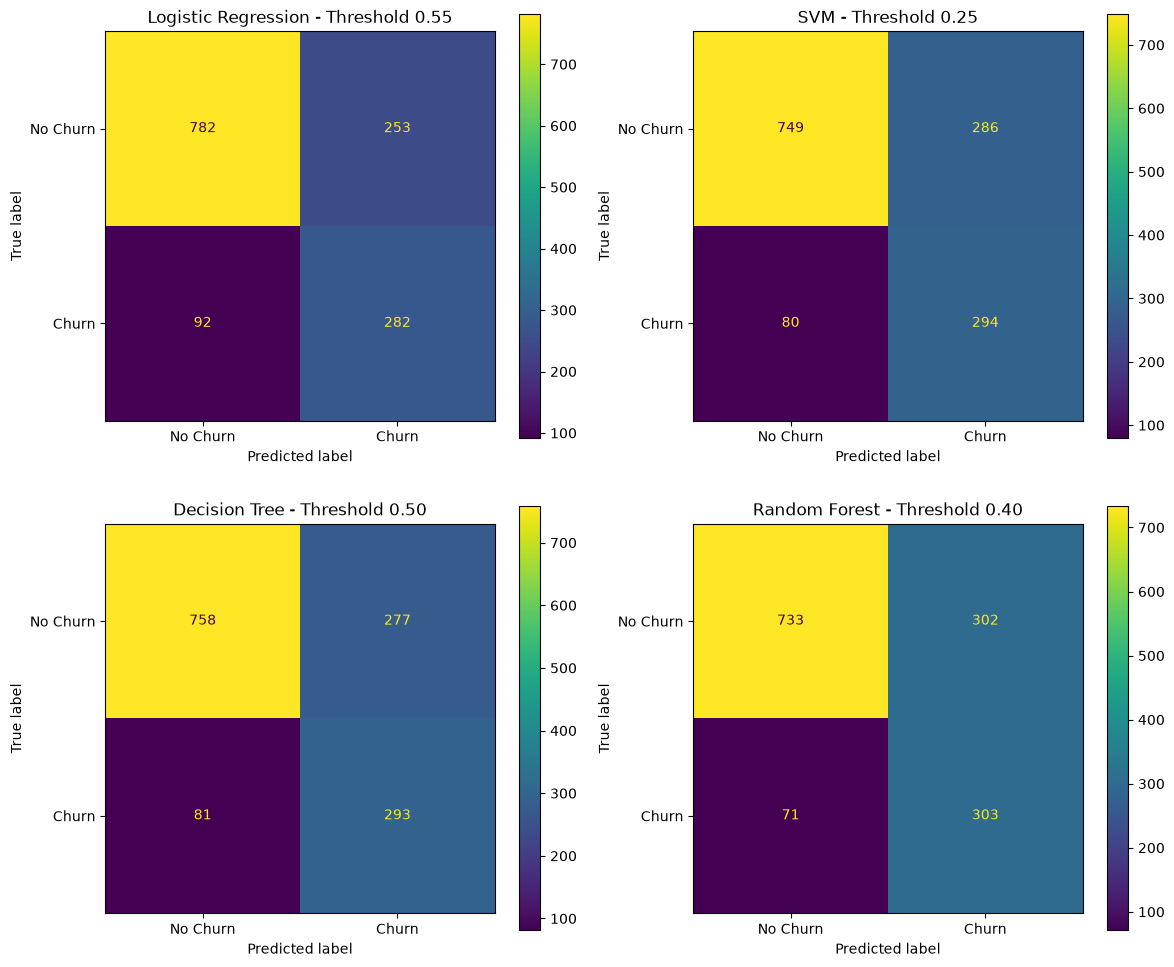

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic_final,
    display_labels=["No Churn", "Churn"],
    ax=axes[0, 0]
)
axes[0, 0].set_title("Logistic Regression - Threshold 0.55")

# SVM
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm_final,
    display_labels=["No Churn", "Churn"],
    ax=axes[0, 1]
)
axes[0, 1].set_title("SVM - Threshold 0.25")

# Decision Tree
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt_final,
    display_labels=["No Churn", "Churn"],
    ax=axes[1, 0]
)
axes[1, 0].set_title("Decision Tree - Threshold 0.50")

# Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_final,
    display_labels=["No Churn", "Churn"],
    ax=axes[1, 1]
)
axes[1, 1].set_title("Random Forest - Threshold 0.40")

plt.tight_layout()
plt.show()

In [63]:
#according to below matrices, Random Forest is the best for classification since It has only 71 false negatives compared with other algorithms
#save the last Random Forest model
import joblib

joblib.dump(best_rf, "random_forest_churn_model.joblib")

#save the threshold
threshold = 0.40

joblib.dump(threshold, "random_forest_churn_threshold.joblib")

['random_forest_churn_threshold.joblib']

In [64]:
#verifying the models
import os

print(os.path.exists("random_forest_churn_model.joblib"))
print(os.path.exists("random_forest_churn_threshold.joblib"))

True
True
